In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100

COLS = ['Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
        'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
        'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed',
        'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']
SENSORS = ['T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30', 'Nf', 'Nc', 'epr',
           'Ps30', 'phi', 'NRf', 'NRc', 'BPR', 'farB', 'htBleed',
           'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32']

In [3]:
def load_dataset(filename):
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None)
    df = df.iloc[:, :26]
    df.columns = COLS
    max_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('max_cycle')
    df = df.join(max_cycle, on='Unit Number')
    df['RUL'] = df['max_cycle'] - df['Time (Cycles)']
    df['life_pct'] = df['Time (Cycles)'] / df['max_cycle']
    return df

df = load_dataset('train_FD001.txt')
print(f'FD001 — rows: {len(df):,}  engines: {df["Unit Number"].nunique()}')

FD001 — rows: 20,631  engines: 100


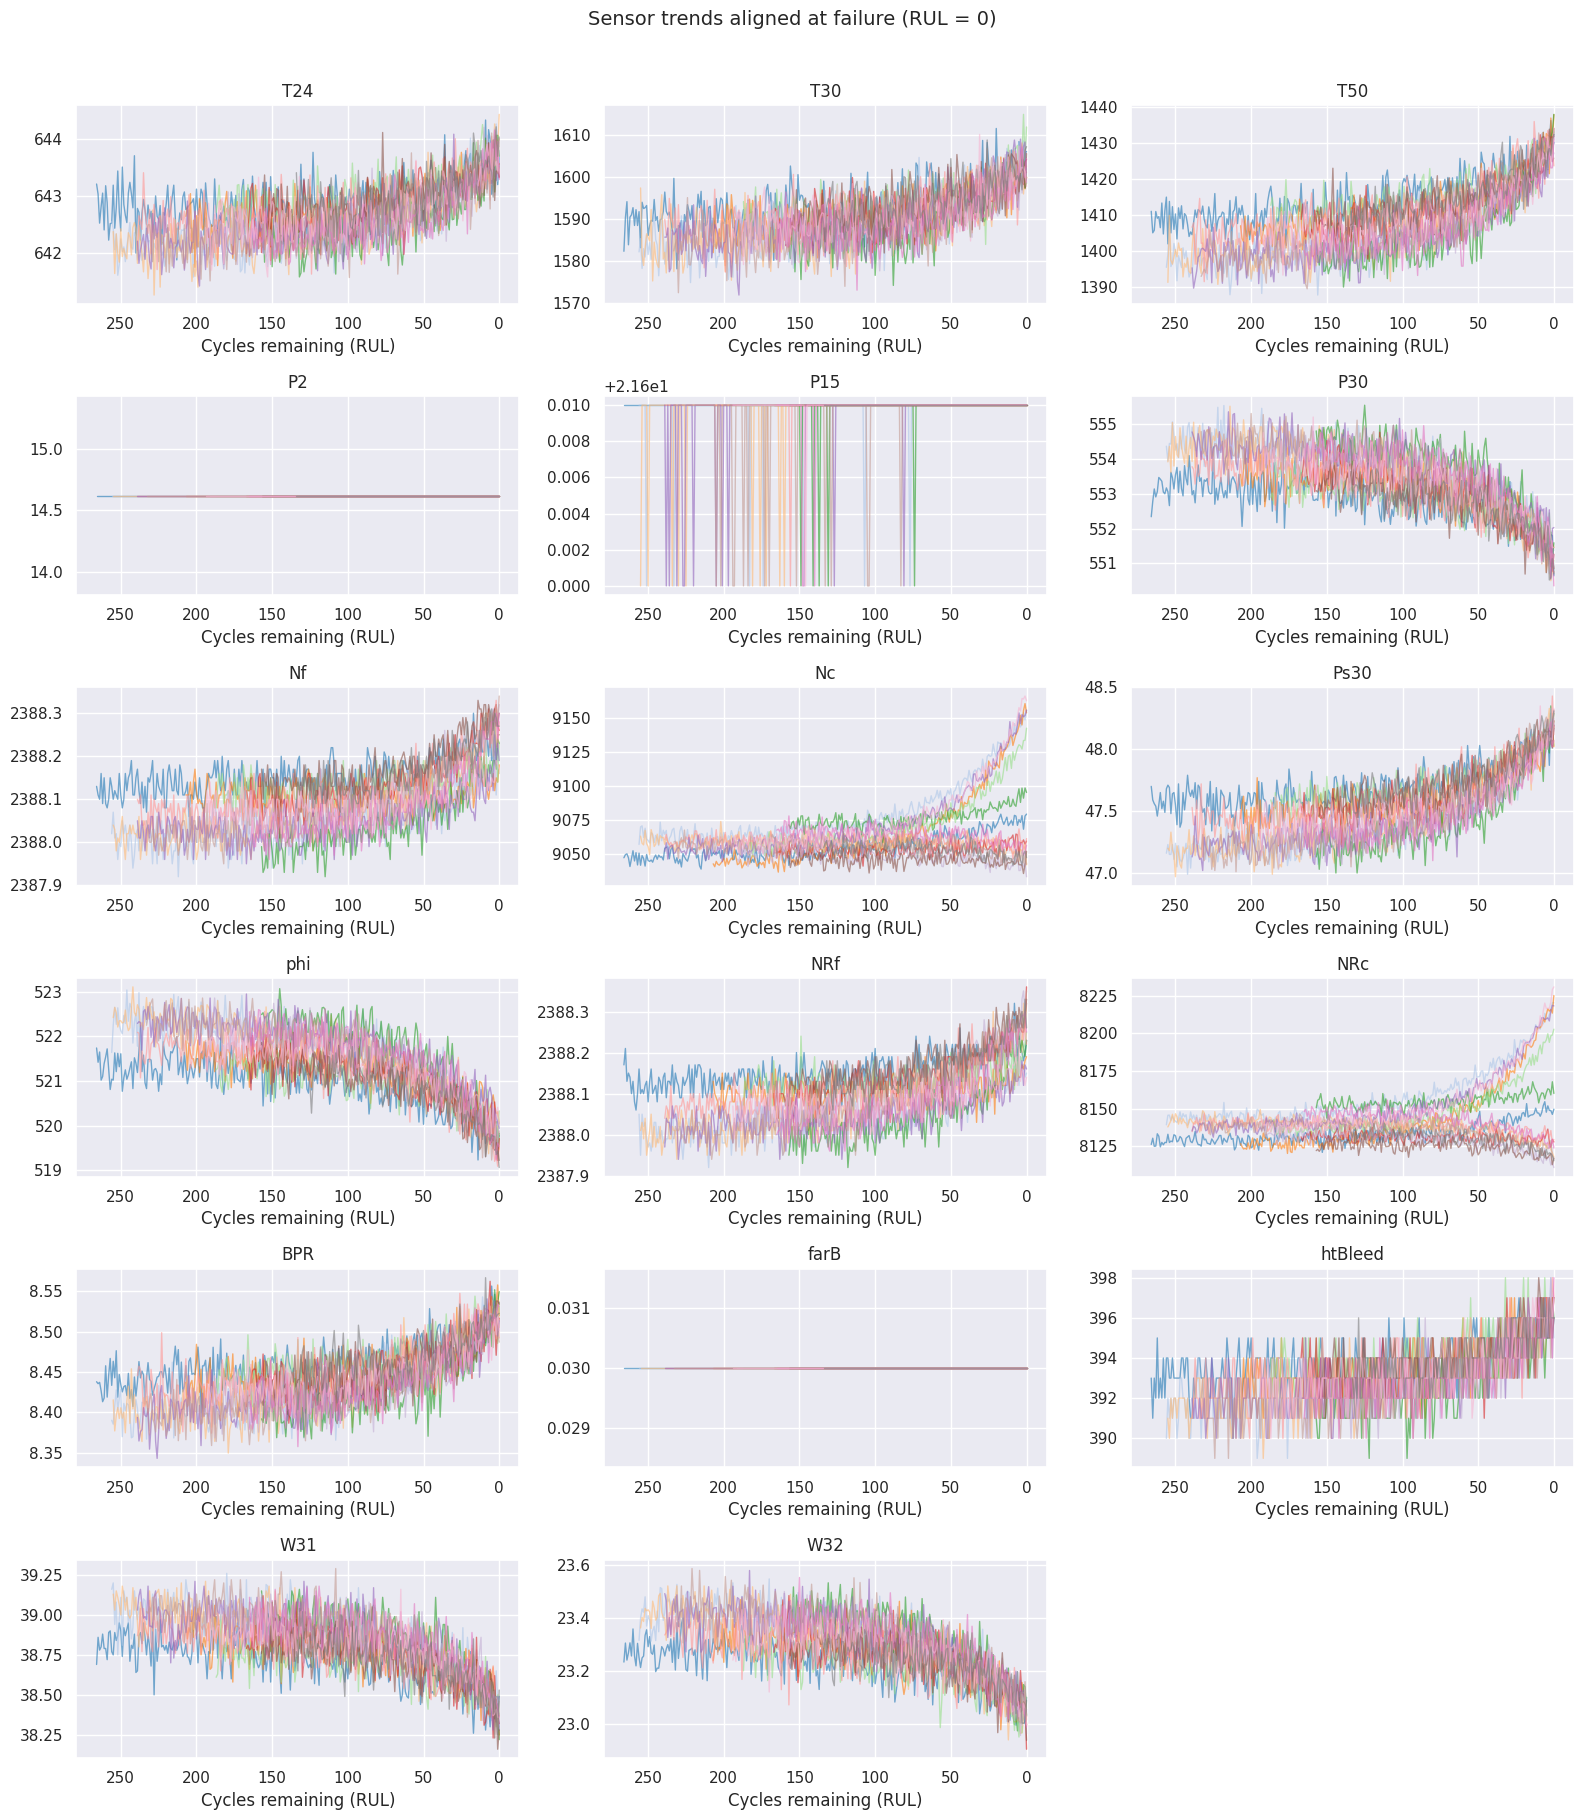

In [4]:
varying_sensors = [s for s in SENSORS if df[s].std() > 0]
sample_engines = df['Unit Number'].drop_duplicates().sample(15, random_state=42).values
colors = sns.color_palette('tab20', len(sample_engines))

ncols = 3
nrows = (len(varying_sensors) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, sensor in enumerate(varying_sensors):
    for unit, color in zip(sample_engines, colors):
        engine = df[df['Unit Number'] == unit].sort_values('RUL', ascending=False)
        axes[i].plot(engine['RUL'], engine[sensor], alpha=0.6, lw=1, color=color)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycles remaining (RUL)')
    axes[i].invert_xaxis()

for ax in axes[len(varying_sensors):]:
    ax.set_visible(False)

fig.suptitle('Sensor trends aligned at failure (RUL = 0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

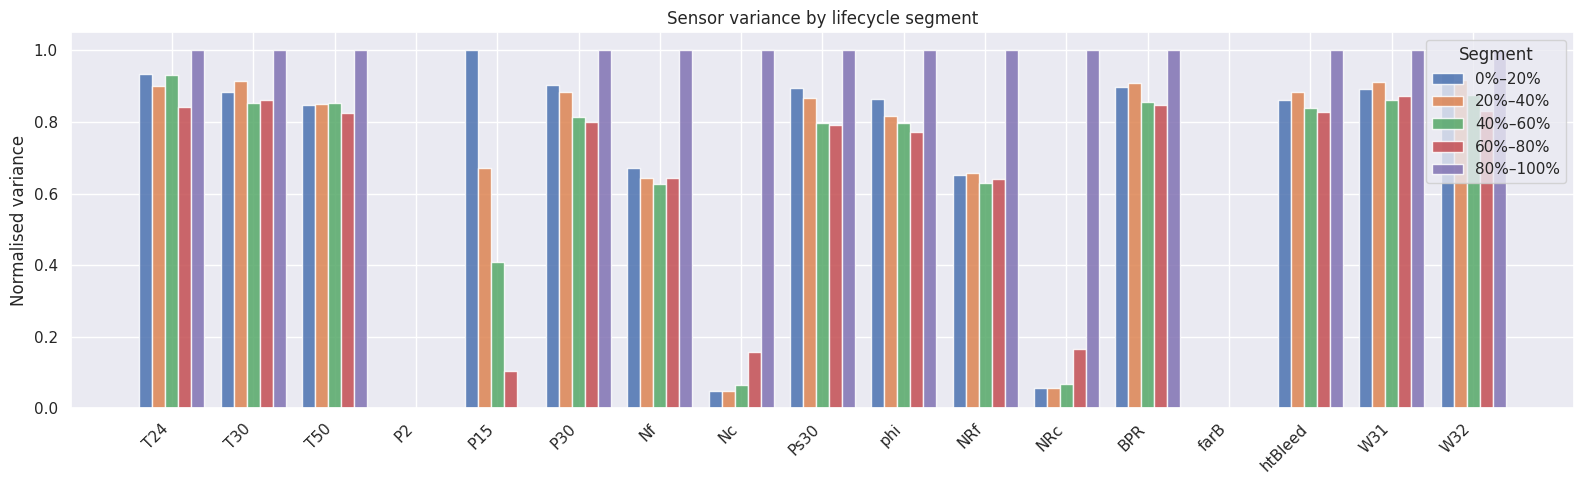

In [5]:
n_parts = 5
bins = np.linspace(0, 1, n_parts + 1)
seg_labels = [f'{bins[i]:.0%}–{bins[i+1]:.0%}' for i in range(n_parts)]
df['segment'] = pd.cut(df['life_pct'], bins=bins, labels=seg_labels, include_lowest=True)

var_df = df.groupby('segment', observed=True)[varying_sensors].var()
var_norm = var_df.div(var_df.max())

x = np.arange(len(varying_sensors))
width = 0.8 / n_parts

fig, ax = plt.subplots(figsize=(16, 5))
for i, (seg, row) in enumerate(var_norm.iterrows()):
    offset = (i - n_parts / 2 + 0.5) * width
    ax.bar(x + offset, row.values, width, label=seg, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(varying_sensors, rotation=45, ha='right')
ax.set_ylabel('Normalised variance')
ax.set_title('Sensor variance by lifecycle segment')
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

## 3. Engine clustering across all datasets
Each point is one engine, represented by the mean of its sensor values across its whole life. PCA reduces the sensors to 2 dimensions so we can plot them. Engines from different datasets (FD001–FD004) use different operating conditions, which should produce visible clusters.

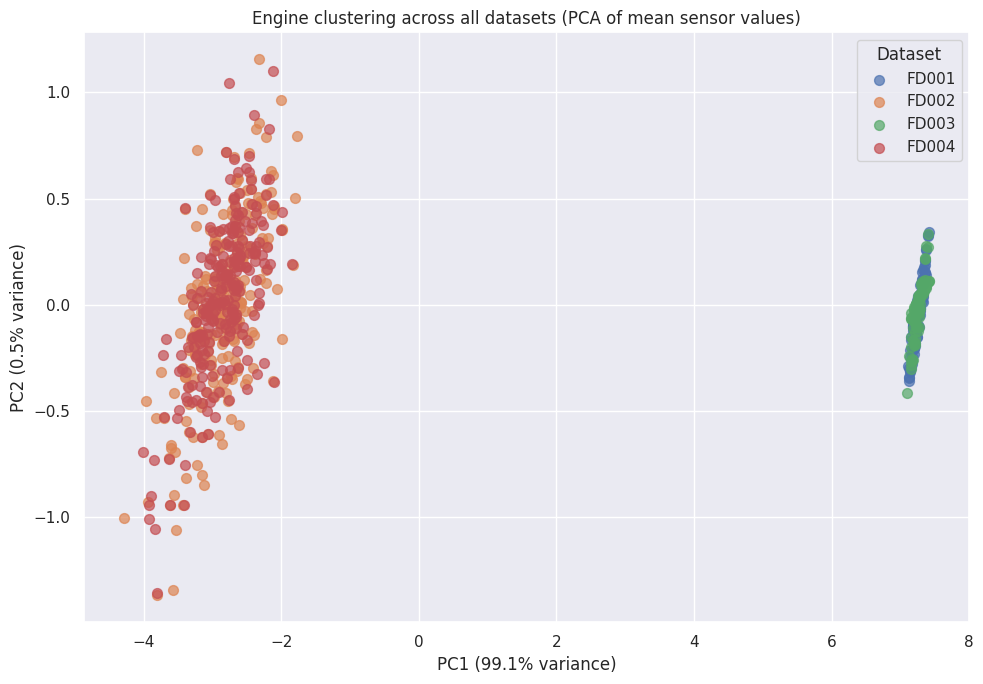

In [6]:
datasets = {'FD001': load_dataset('train_FD001.txt'),
            'FD002': load_dataset('train_FD002.txt'),
            'FD003': load_dataset('train_FD003.txt'),
            'FD004': load_dataset('train_FD004.txt')}

engine_means = []
for name, d in datasets.items():
    means = d.groupby('Unit Number')[SENSORS].mean()
    means['dataset'] = name
    engine_means.append(means)

engine_means = pd.concat(engine_means)

X = engine_means[SENSORS].values
X_scaled = StandardScaler().fit_transform(X)
coords = PCA(n_components=2).fit_transform(X_scaled)
pca_model = PCA(n_components=2).fit(X_scaled)

engine_means['PC1'] = coords[:, 0]
engine_means['PC2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for dataset, group in engine_means.groupby('dataset'):
    ax.scatter(group['PC1'], group['PC2'], label=dataset, alpha=0.7, s=50)

ax.set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Engine clustering across all datasets (PCA of mean sensor values)')
ax.legend(title='Dataset')
plt.tight_layout()
plt.show()

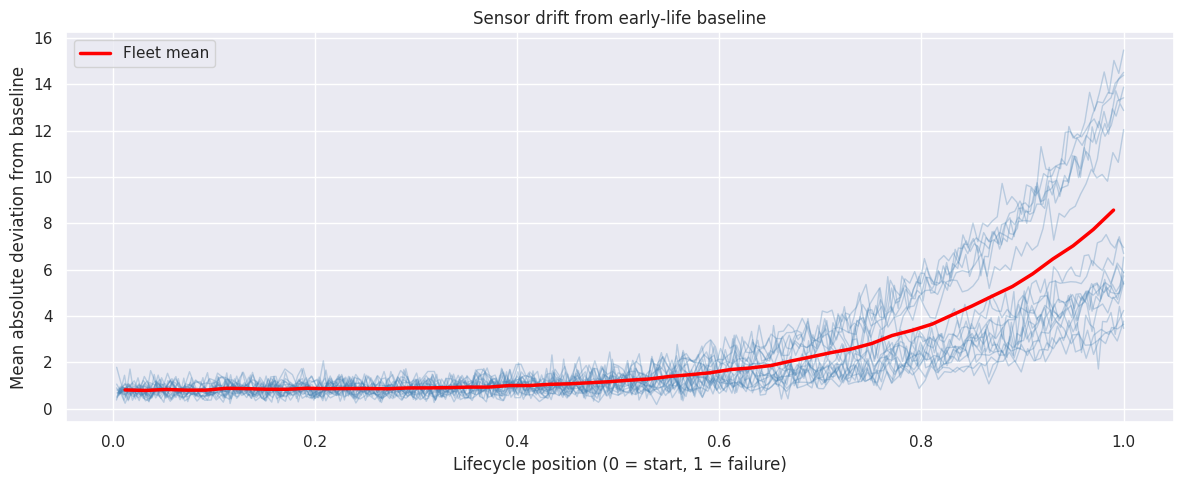

In [7]:
baseline = (df[df['life_pct'] <= 0.1]
            .groupby('Unit Number')[varying_sensors]
            .mean()
            .add_suffix('_baseline'))

df4 = df.join(baseline, on='Unit Number')

for s in varying_sensors:
    df4[f'{s}_dist'] = (df4[s] - df4[f'{s}_baseline']).abs()

dist_cols = [f'{s}_dist' for s in varying_sensors]
df4['mean_drift'] = df4[dist_cols].mean(axis=1)

sample_engines = df['Unit Number'].drop_duplicates().sample(20, random_state=42).values

fig, ax = plt.subplots(figsize=(12, 5))
for unit in sample_engines:
    eng = df4[df4['Unit Number'] == unit].sort_values('life_pct')
    ax.plot(eng['life_pct'], eng['mean_drift'], alpha=0.3, lw=1, color='steelblue')

fleet_mean = (df4.groupby(pd.cut(df4['life_pct'], bins=50), observed=True)['mean_drift']
              .mean())
midpoints = [interval.mid for interval in fleet_mean.index]
ax.plot(midpoints, fleet_mean.values, color='red', lw=2.5, label='Fleet mean')

ax.set_xlabel('Lifecycle position (0 = start, 1 = failure)')
ax.set_ylabel('Mean absolute deviation from baseline')
ax.set_title('Sensor drift from early-life baseline')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
offset = 0
parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_dataset(f'train_{fd}.txt')
    d['Unit Number'] += offset
    d['dataset'] = fd
    offset = d['Unit Number'].max()
    parts.append(d)

df_all = pd.concat(parts, ignore_index=True)
ds_palette = {'FD001': '#4C72B0', 'FD002': '#DD8452', 'FD003': '#55A868', 'FD004': '#C44E52'}
varying_all = [s for s in SENSORS if df_all[s].std() > 0]

print(f'Total rows: {len(df_all):,}  |  Engines: {df_all["Unit Number"].nunique()}')

Total rows: 160,359  |  Engines: 709


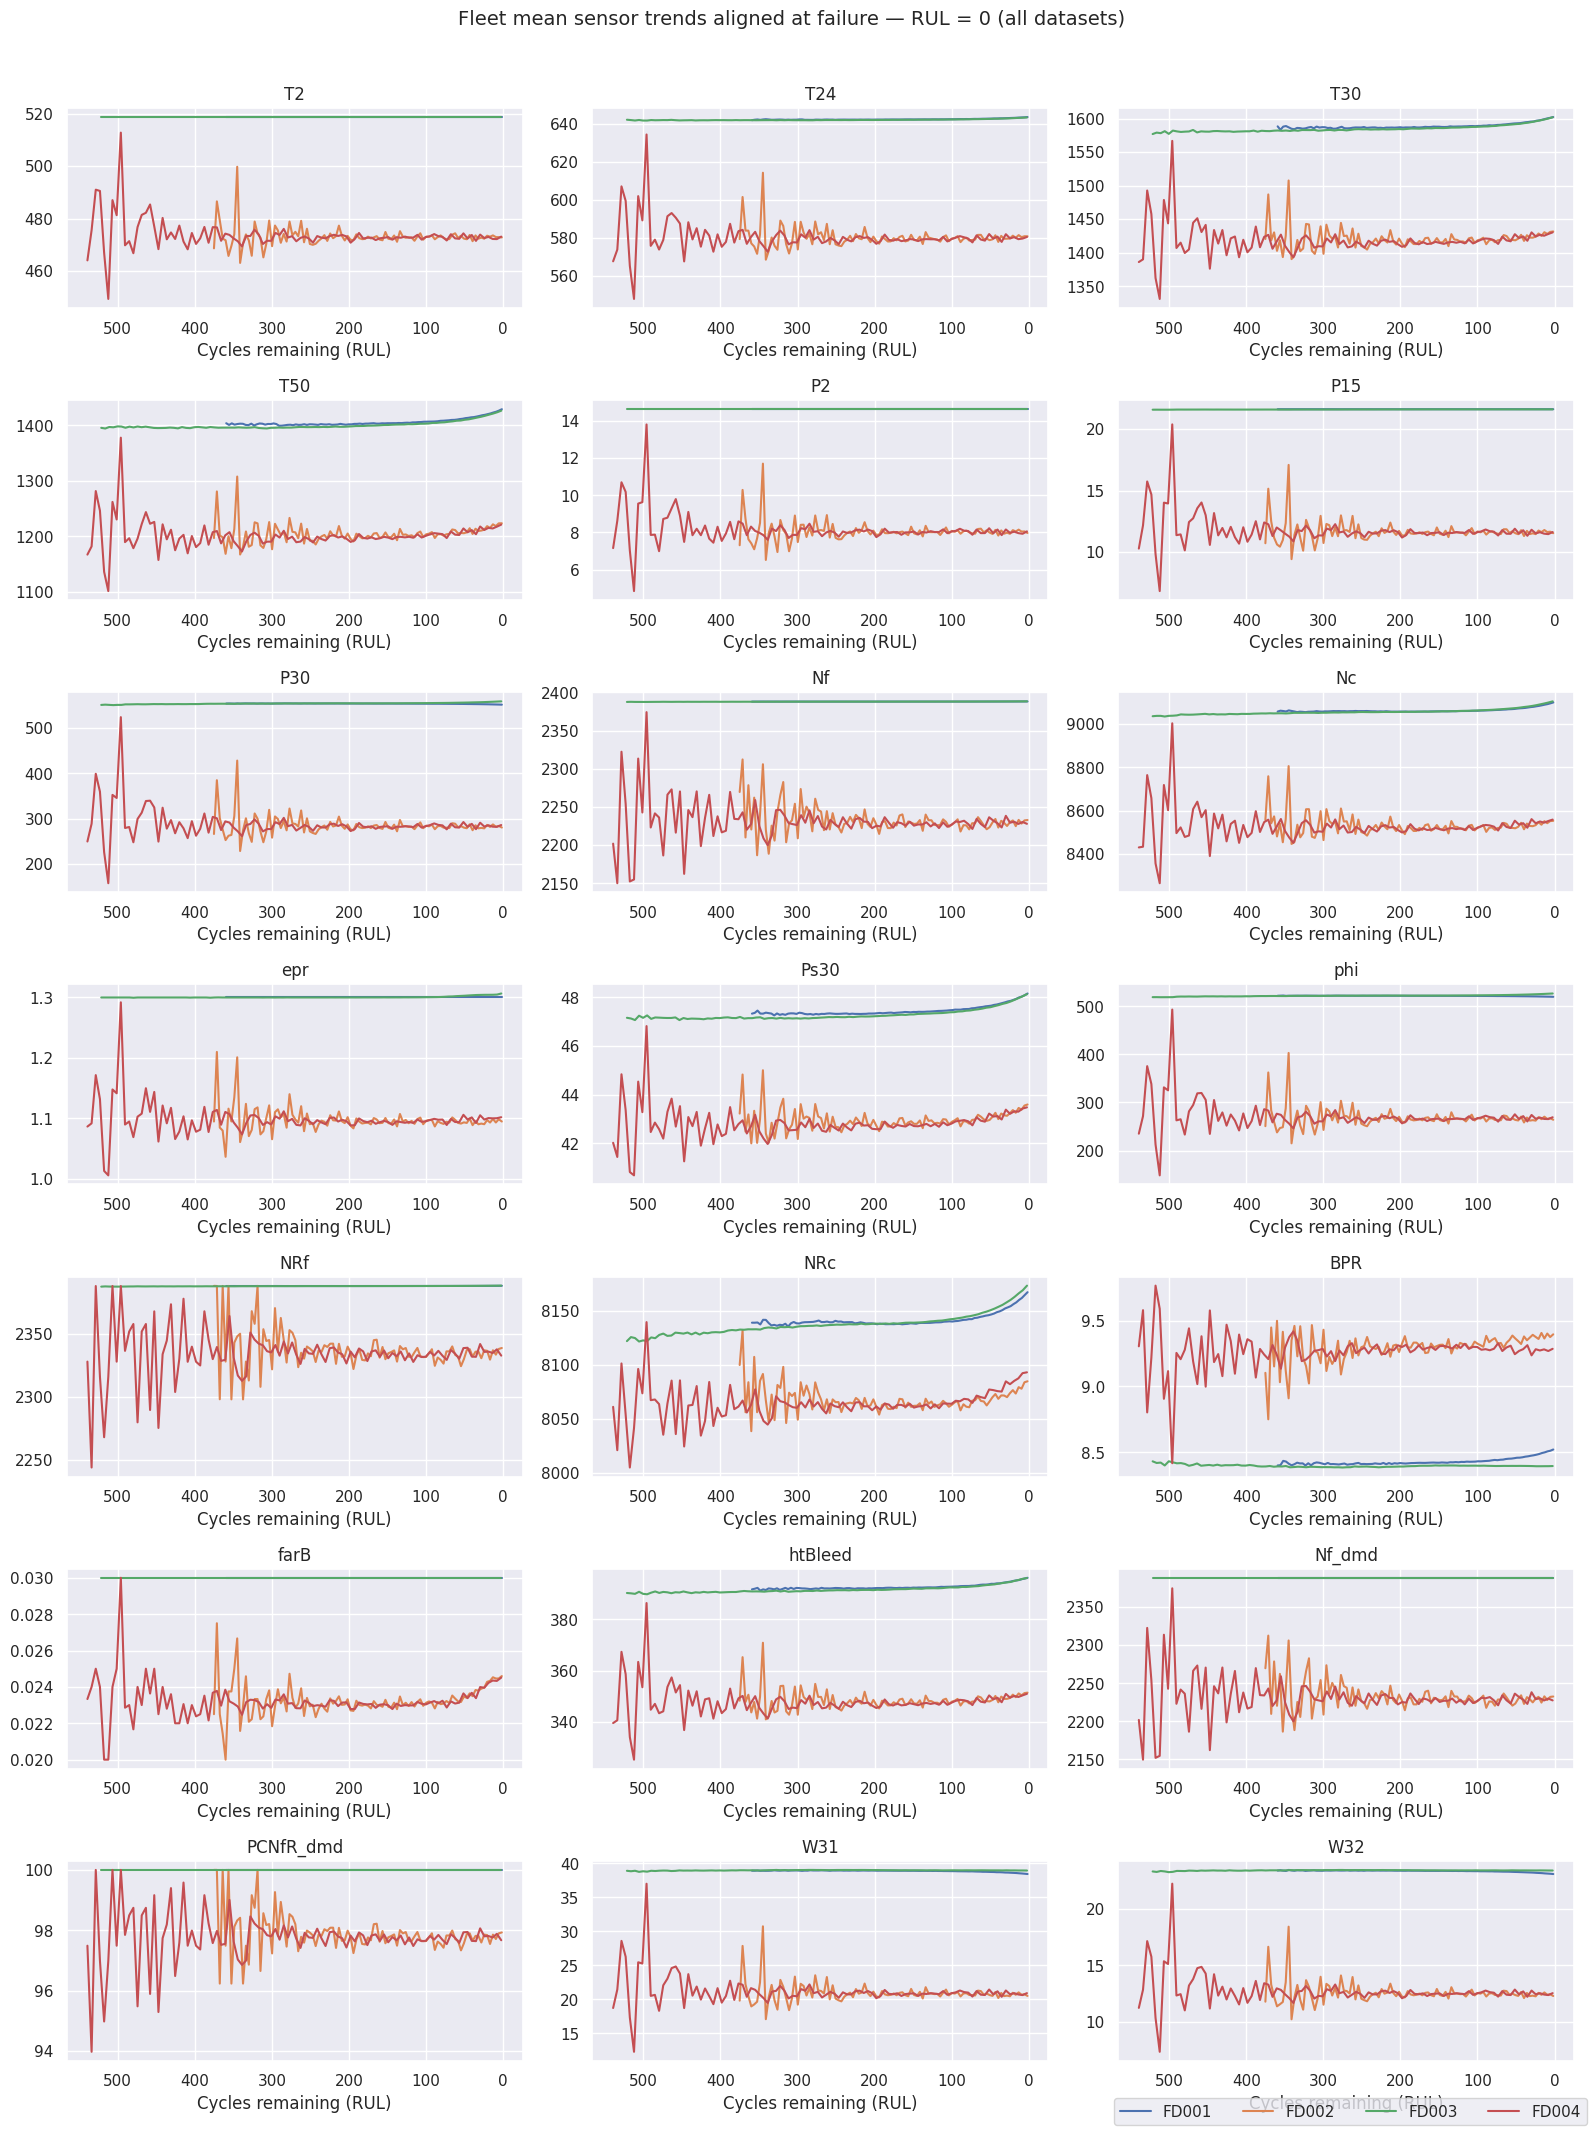

In [9]:
ncols = 3
nrows = (len(varying_all) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, sensor in enumerate(varying_all):
    for fd, group in df_all.groupby('dataset'):
        rul_bins = pd.cut(group['RUL'], bins=100)
        mean_by_rul = group.groupby(rul_bins, observed=True)[sensor].mean()
        midpoints = [b.mid for b in mean_by_rul.index]
        axes[i].plot(midpoints, mean_by_rul.values, lw=1.5, color=ds_palette[fd])
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycles remaining (RUL)')
    axes[i].invert_xaxis()

for ax in axes[len(varying_all):]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], color=ds_palette[fd], label=fd) for fd in ds_palette]
fig.legend(handles=handles, loc='lower right', ncol=4)
fig.suptitle('Fleet mean sensor trends aligned at failure — RUL = 0 (all datasets)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

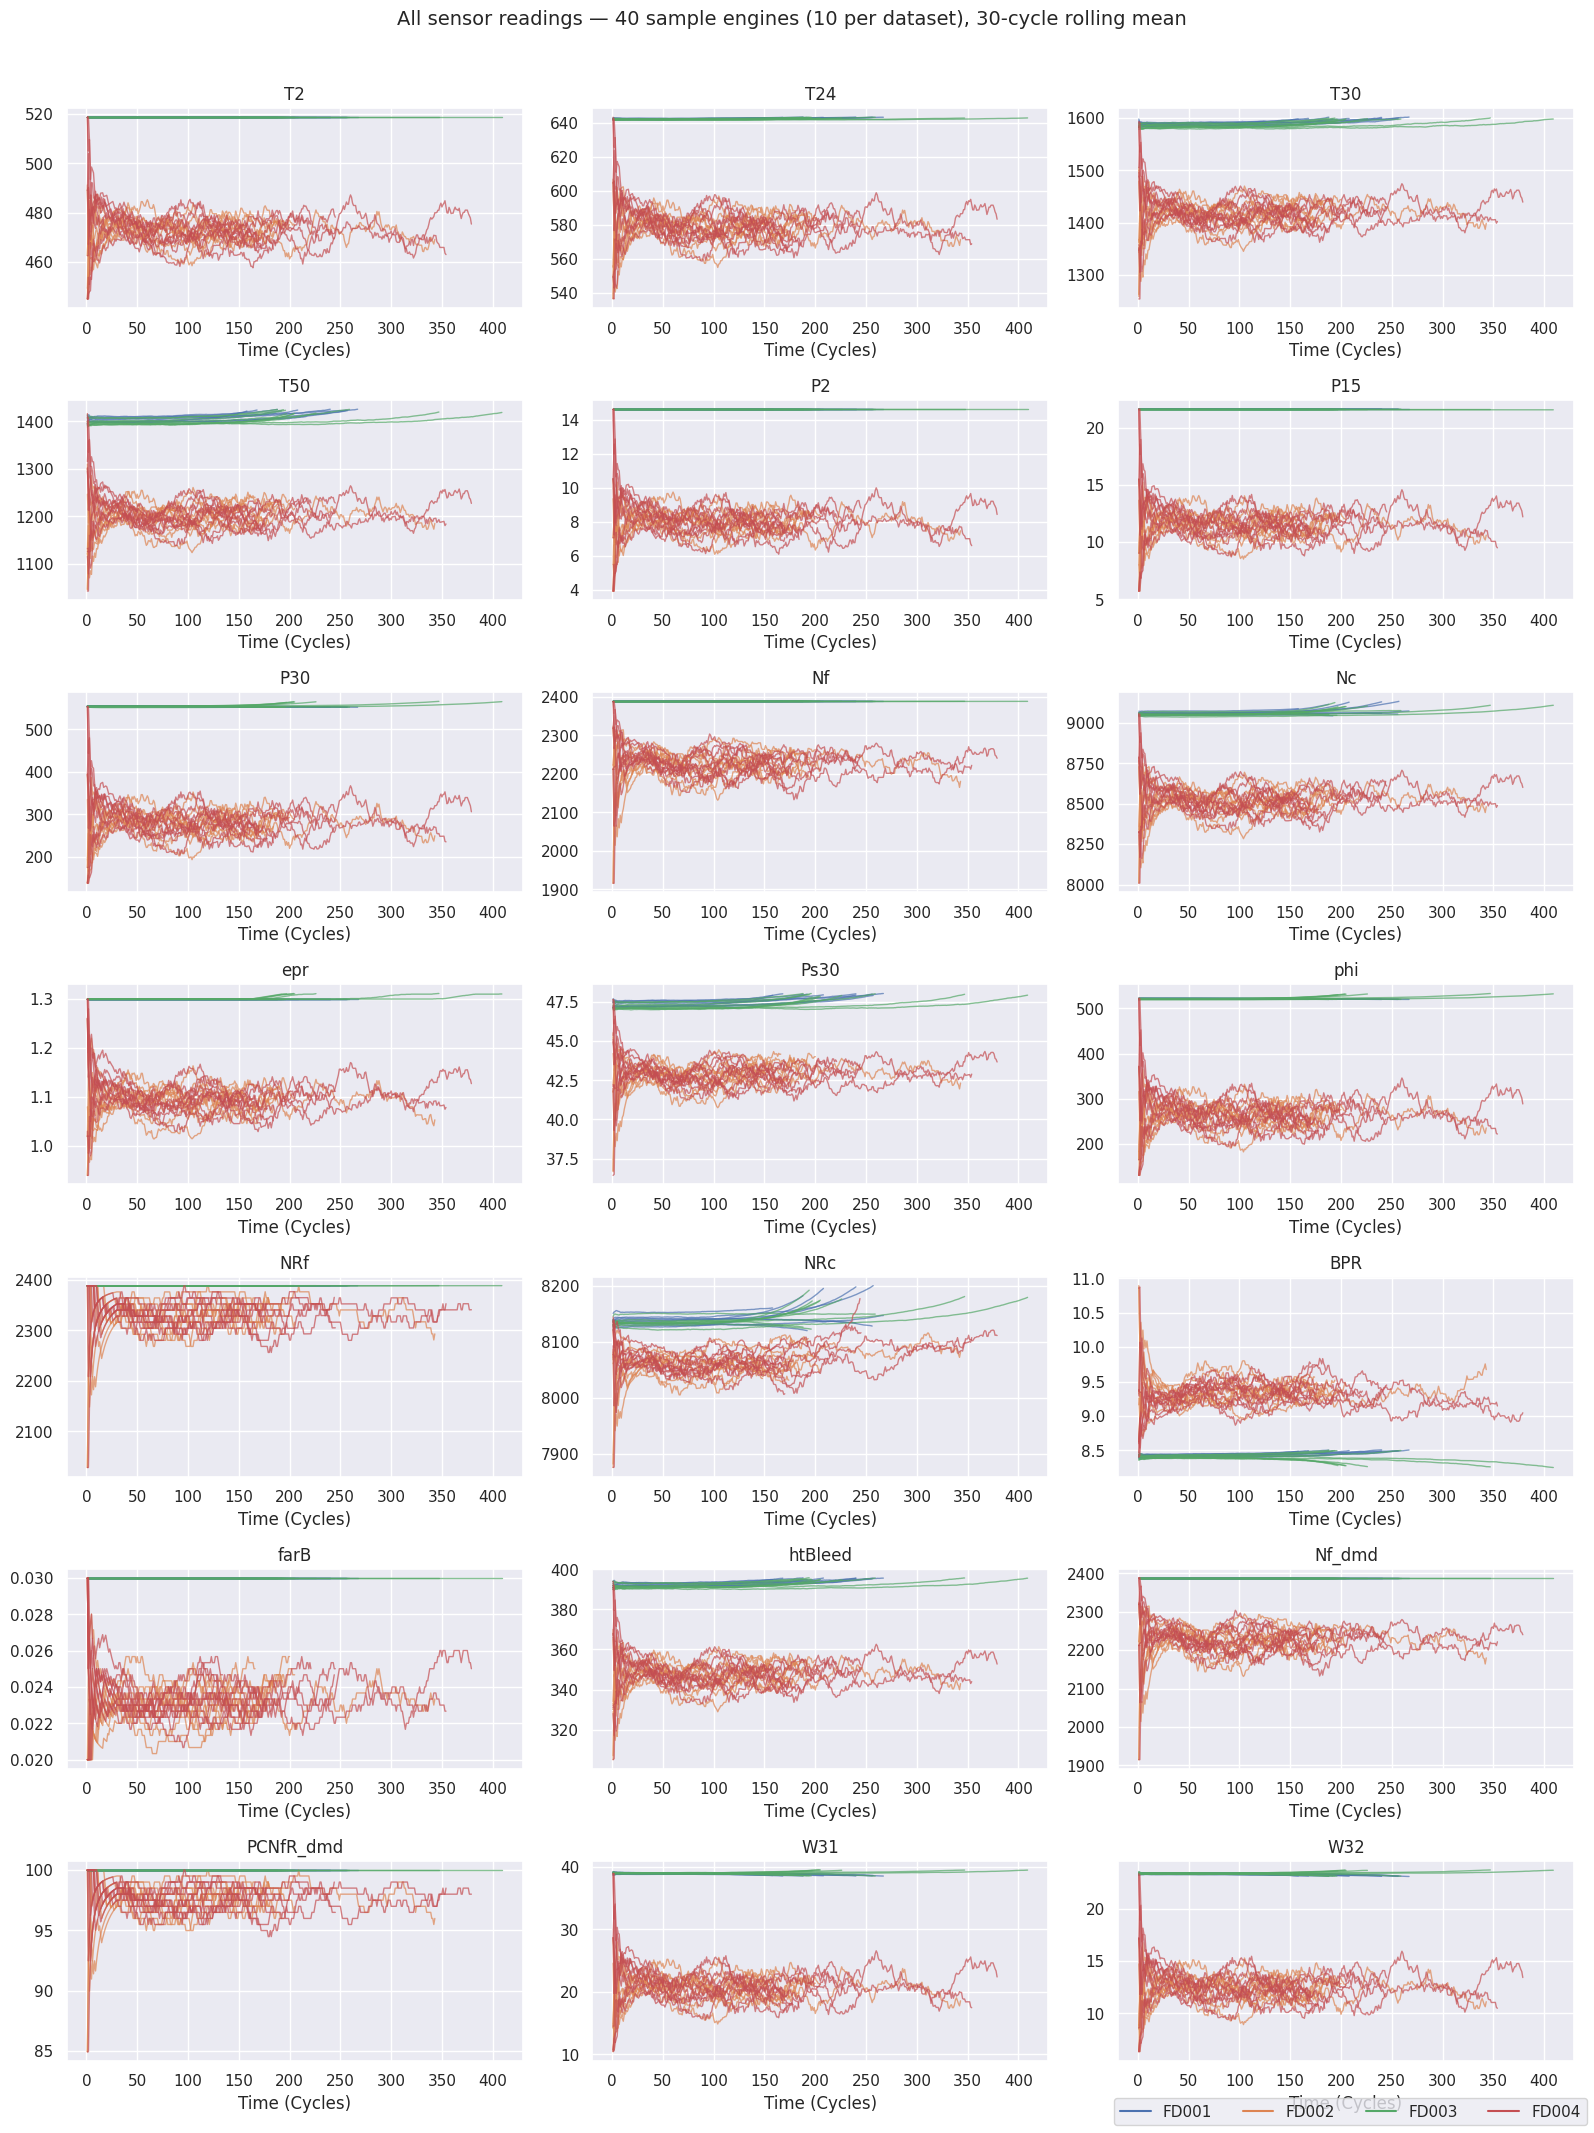

In [10]:
sample_40 = (df_all.groupby('dataset')['Unit Number']
             .apply(lambda x: x.drop_duplicates().sample(10, random_state=42))
             .reset_index(level=0))

def plot_sensors(data, sample_df, title, window=None):
    ncols = 3
    nrows = (len(SENSORS) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for i, sensor in enumerate(SENSORS):
        for _, row in sample_df.iterrows():
            eng = data[data['Unit Number'] == row['Unit Number']].sort_values('Time (Cycles)')
            y = eng[sensor].rolling(window, min_periods=1).mean() if window else eng[sensor]
            axes[i].plot(eng['Time (Cycles)'], y, alpha=0.7, lw=1,
                         color=ds_palette[row['dataset']])
        axes[i].set_title(sensor)
        axes[i].set_xlabel('Time (Cycles)')

    for ax in axes[len(SENSORS):]:
        ax.set_visible(False)

    handles = [plt.Line2D([0], [0], color=ds_palette[fd], label=fd) for fd in ds_palette]
    fig.legend(handles=handles, loc='lower right', ncol=4)
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

plot_sensors(df_all, sample_40,
             'All sensor readings — 40 sample engines (10 per dataset), 30-cycle rolling mean',
             window=30)

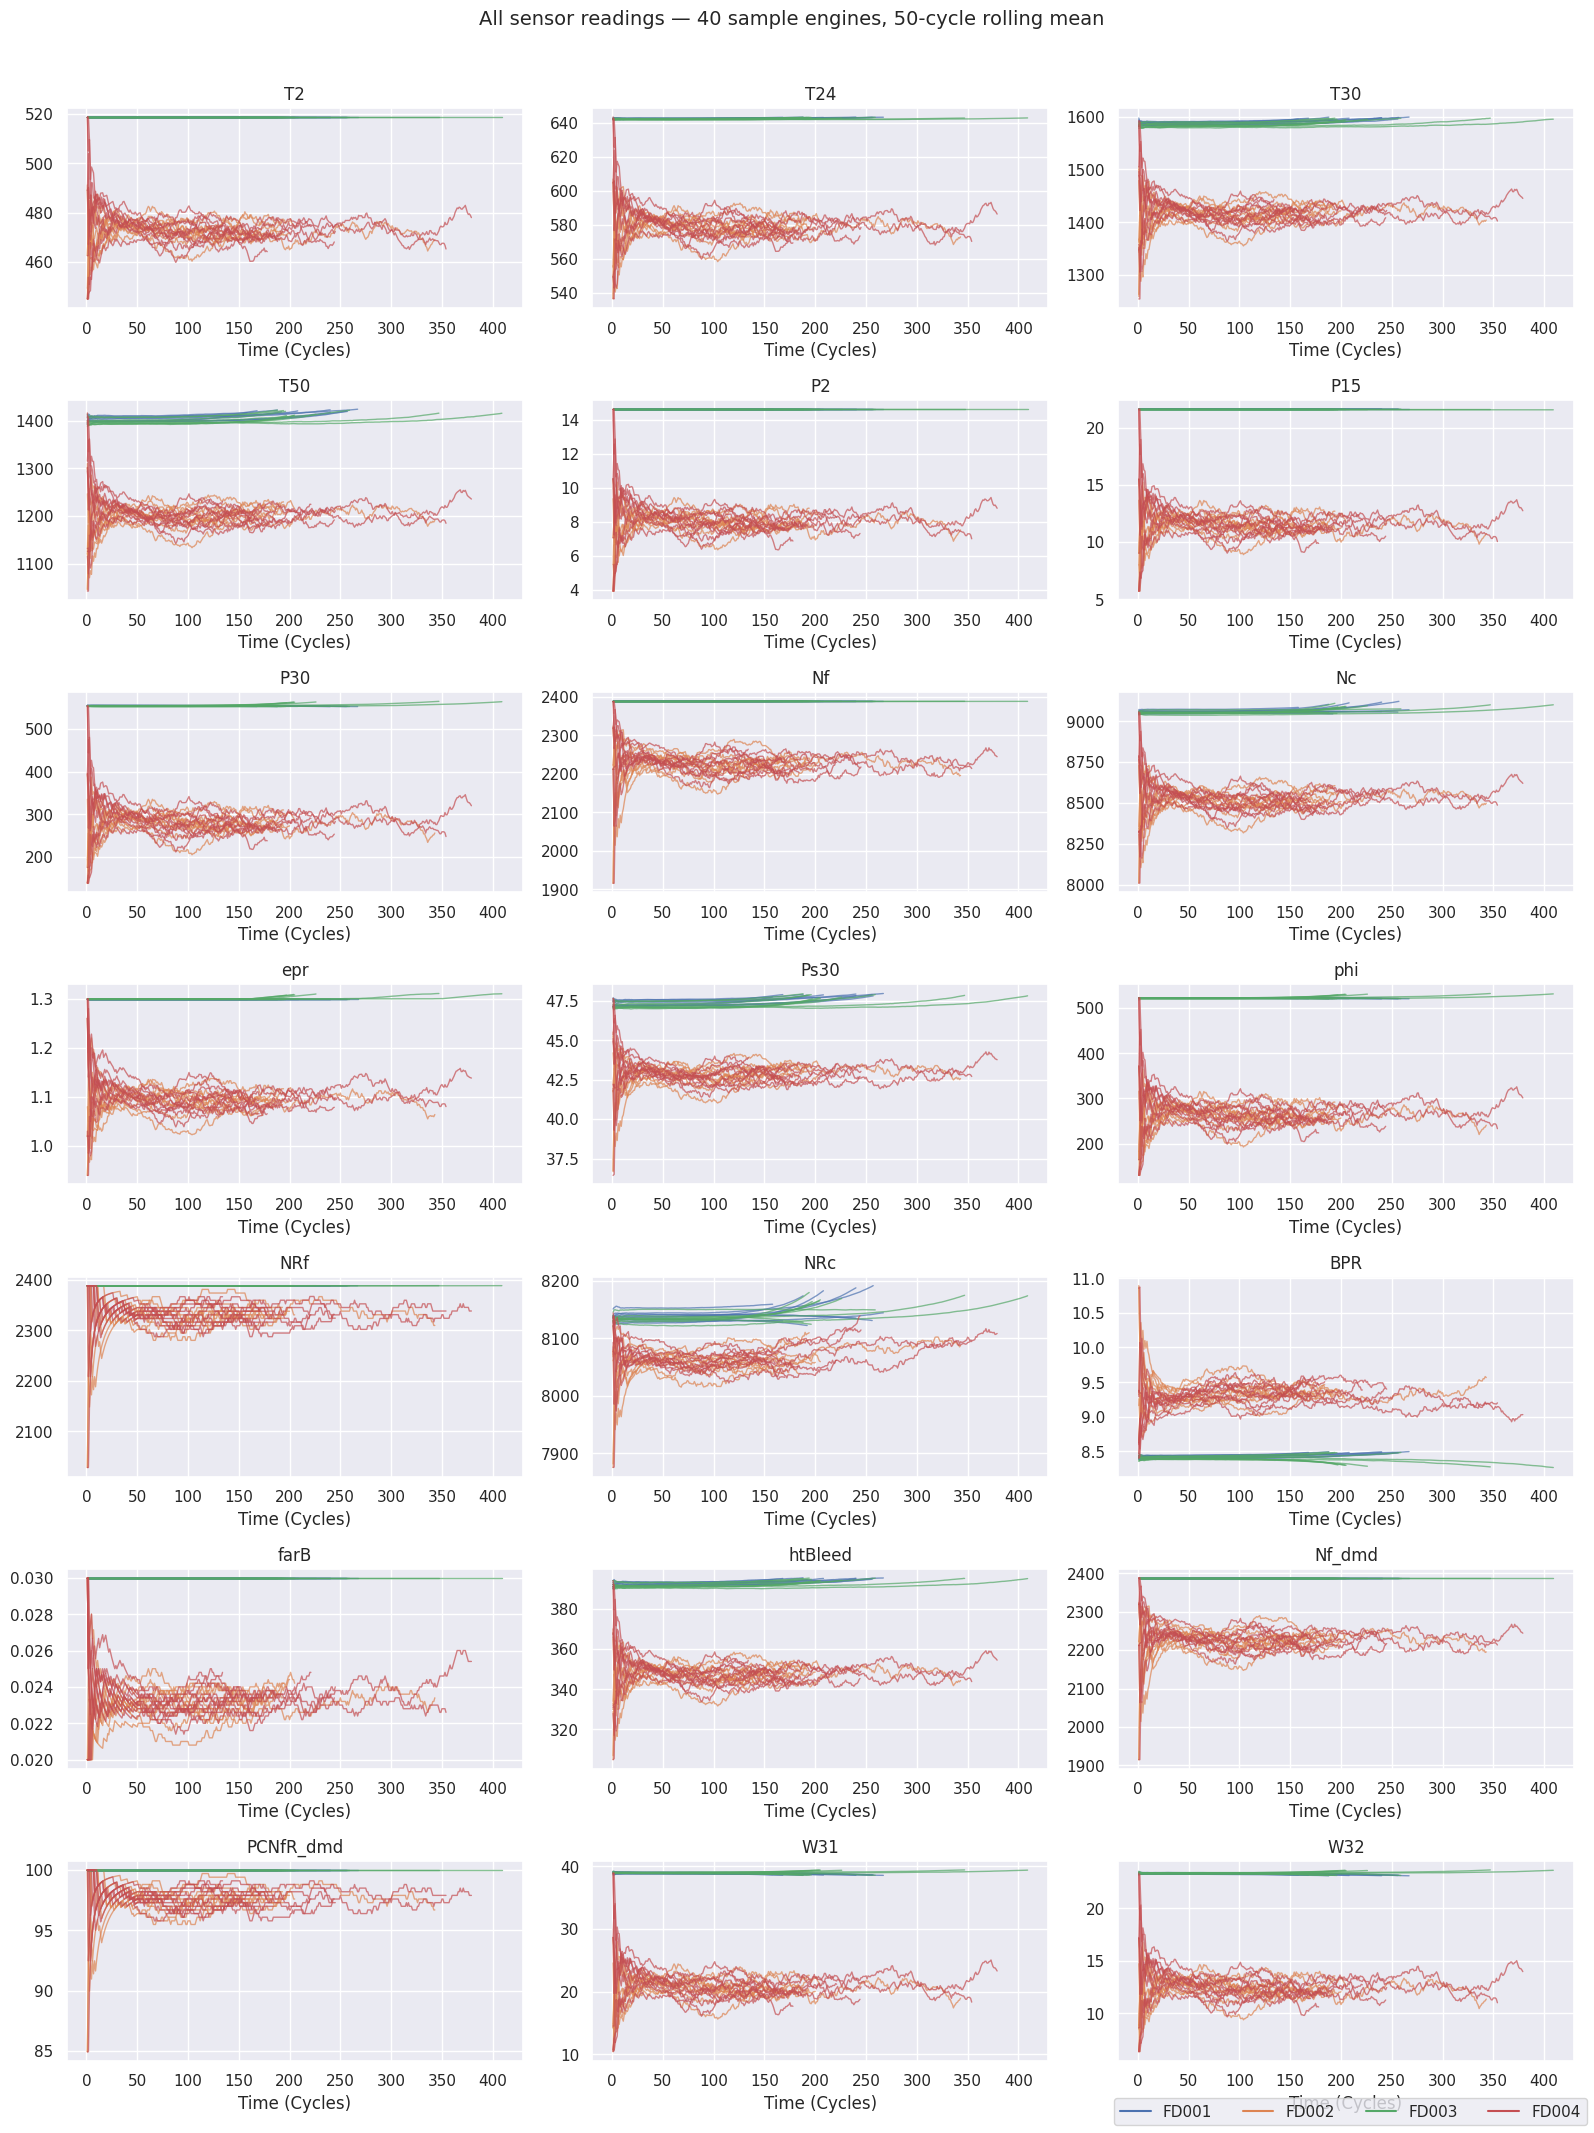

In [11]:
plot_sensors(df_all, sample_40,
             'All sensor readings — 40 sample engines, 50-cycle rolling mean',
             window=50)

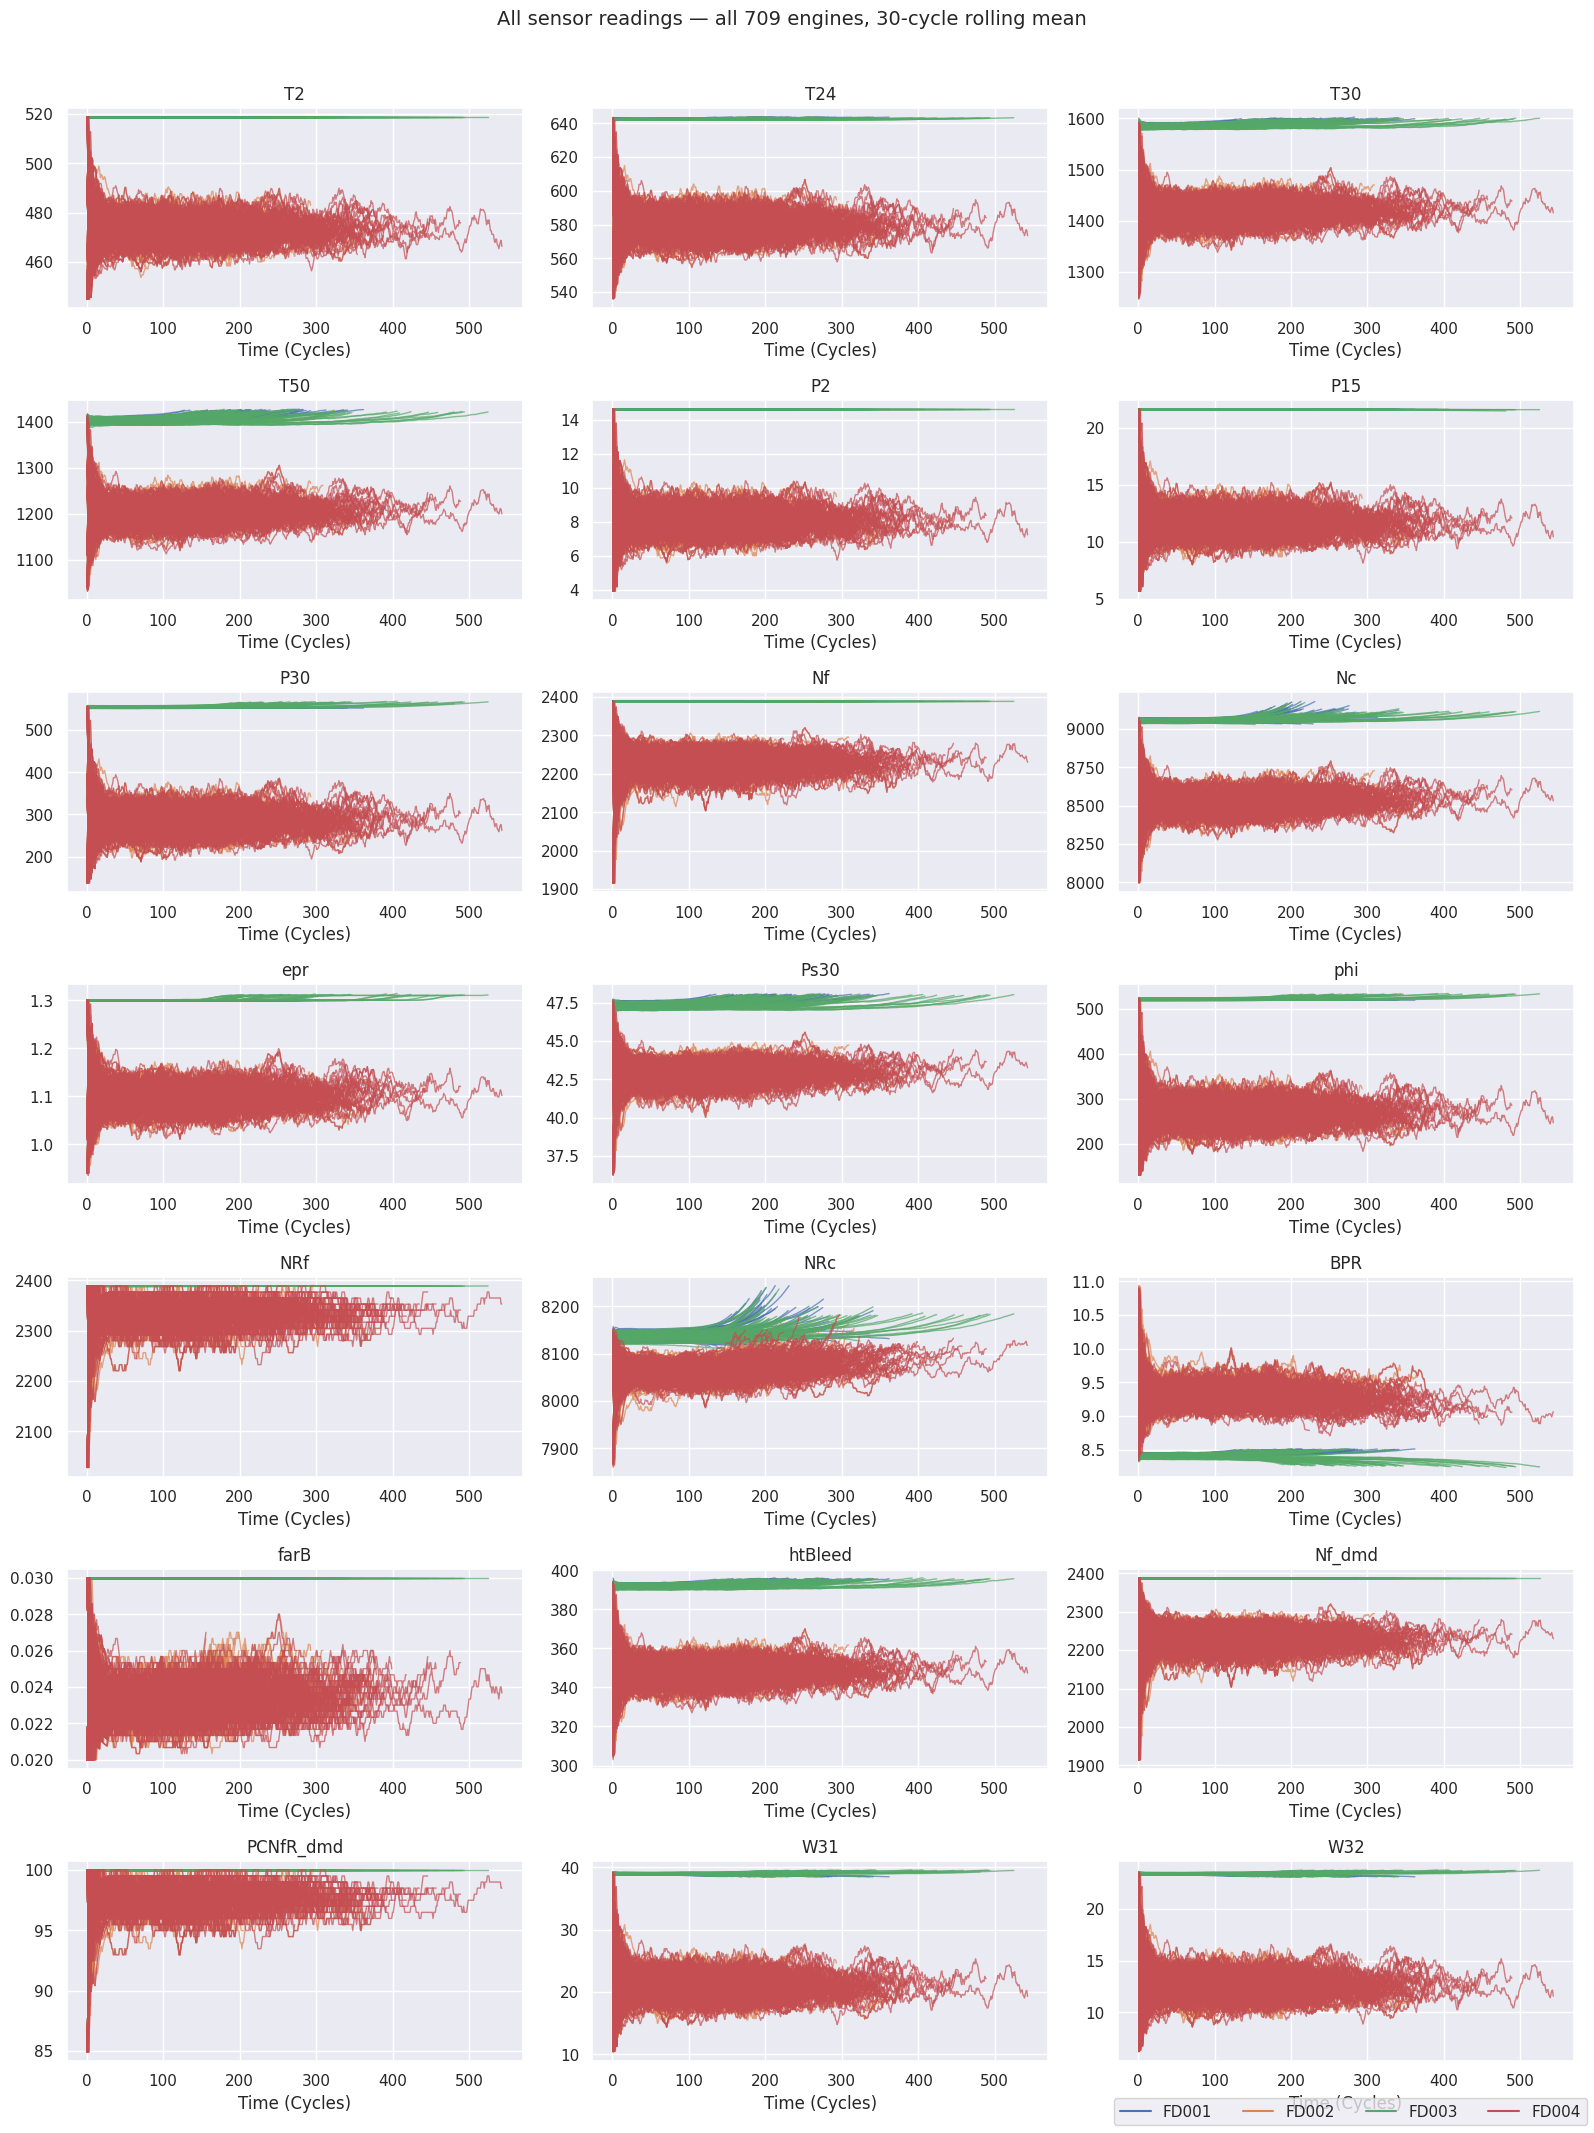

In [12]:
all_engines = (df_all[['dataset', 'Unit Number']]
               .drop_duplicates())

plot_sensors(df_all, all_engines,
             f'All sensor readings — all {all_engines["Unit Number"].nunique()} engines, 30-cycle rolling mean',
             window=30)

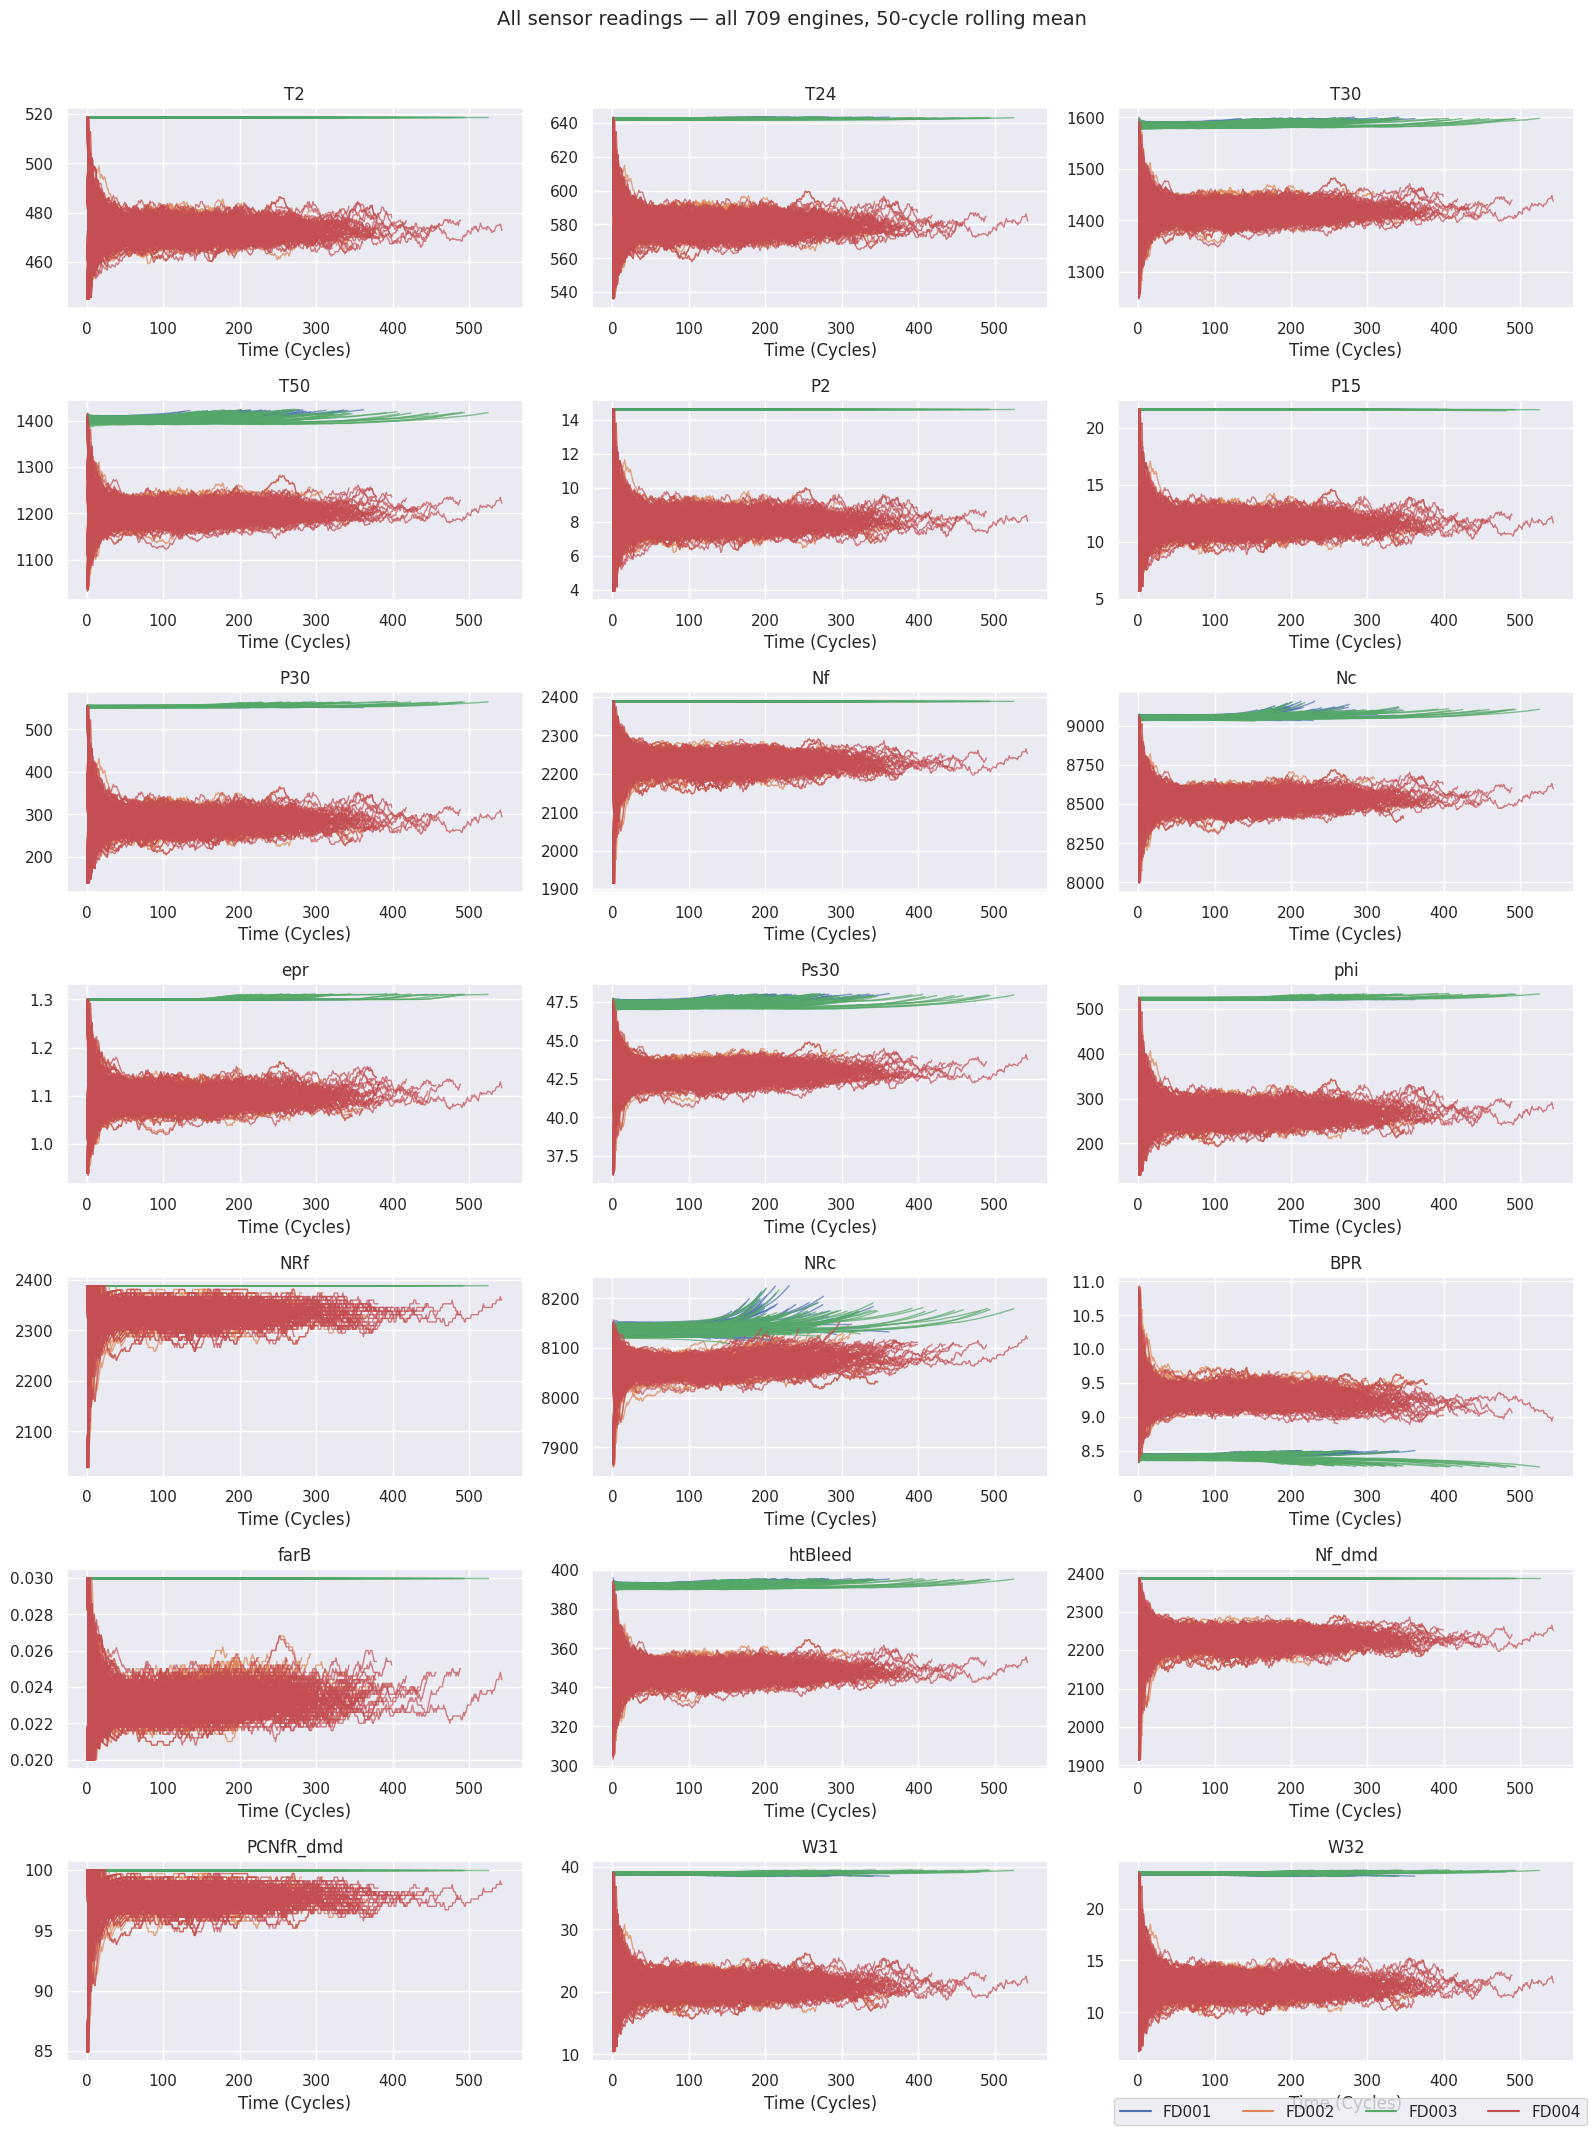

In [13]:
plot_sensors(df_all, all_engines,
             f'All sensor readings — all {all_engines["Unit Number"].nunique()} engines, 50-cycle rolling mean',
             window=50)

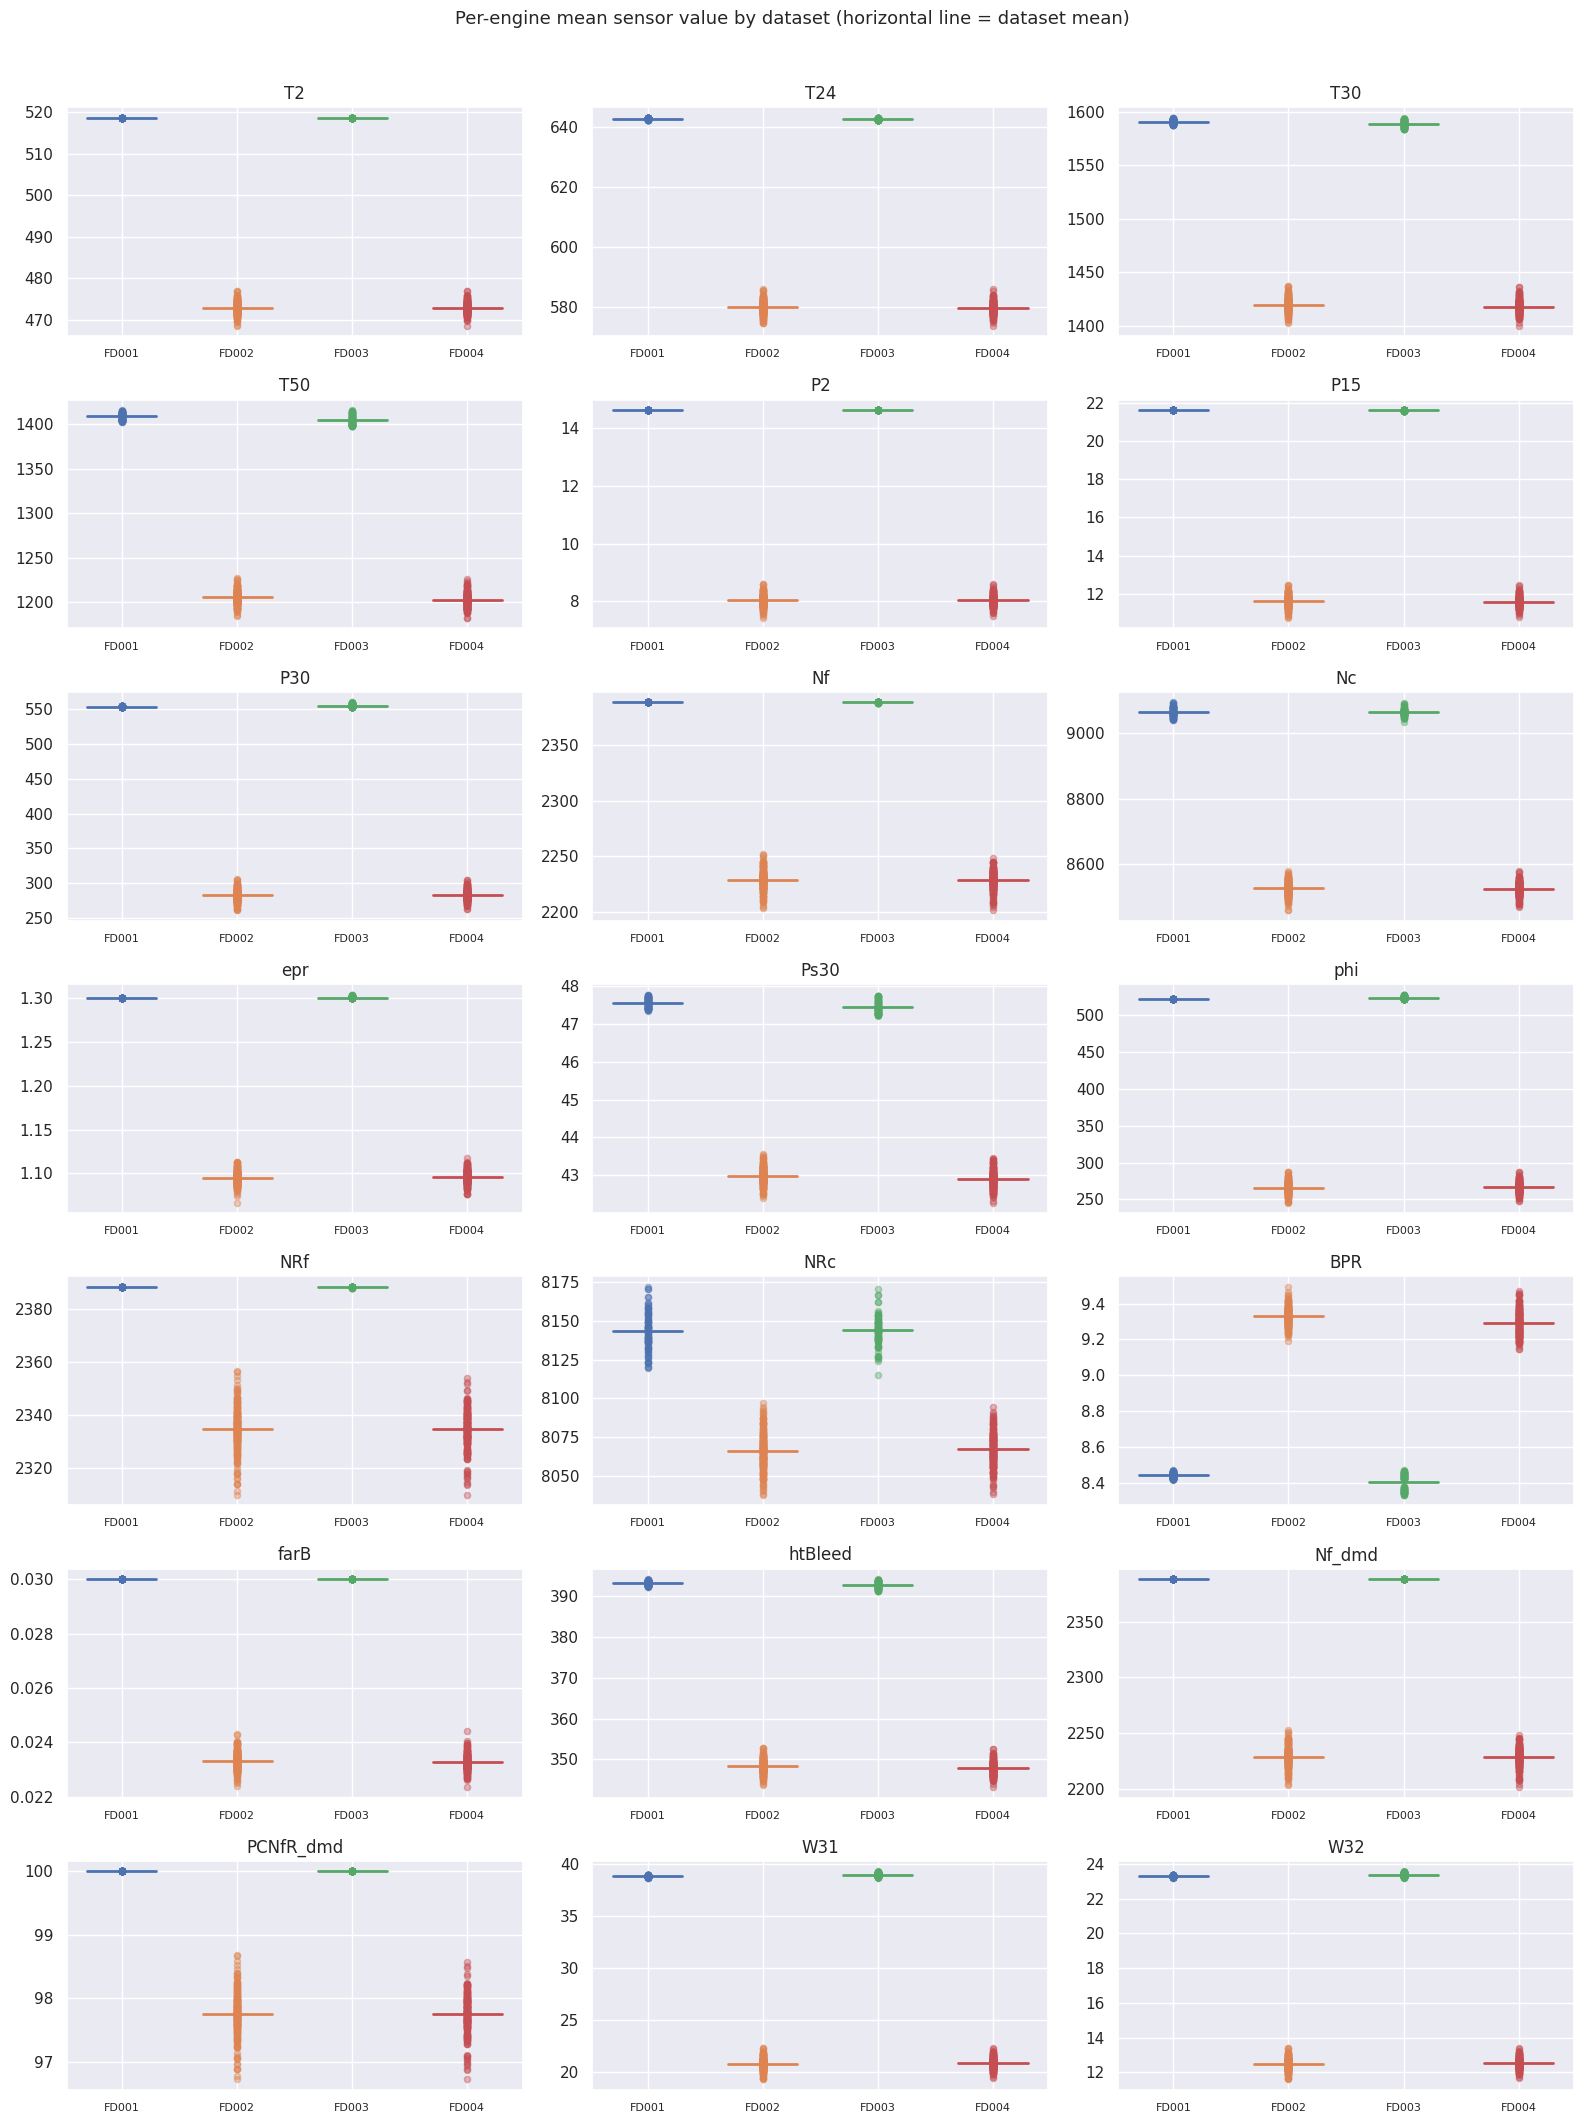

In [14]:
engine_sensor_means = (df_all.groupby(['dataset', 'Unit Number'])[SENSORS]
                       .mean()
                       .reset_index())

ncols = 3
nrows = (len(SENSORS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, sensor in enumerate(SENSORS):
    ax = axes[i]
    for j, (fd, group) in enumerate(engine_sensor_means.groupby('dataset')):
        ax.scatter([j] * len(group), group[sensor],
                   color=ds_palette[fd], alpha=0.4, s=20, label=fd)
        ax.plot([j - 0.3, j + 0.3], [group[sensor].mean()] * 2,
                color=ds_palette[fd], lw=2)
    ax.set_title(sensor)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['FD001', 'FD002', 'FD003', 'FD004'], fontsize=8)

for ax in axes[len(SENSORS):]:
    ax.set_visible(False)

fig.suptitle('Per-engine mean sensor value by dataset (horizontal line = dataset mean)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()